pandas central récupérer des données et les utiliser dans vos modèles
notamment pour les données "temporelles" => données qui sont datés 

date           prix
01/01/2026 => 100 000
02/01/2026 => 120 000
03/01/2026 => 110 000


# cours de bourse du bitcoin

- <https://www.coingecko.com/en/coins/bitcoin/historical_data?start=2010-06-13&end=2026-06-13>

# cours de bourse de etherium

- <https://www.coingecko.com/en/coins/ethereum/historical_data?start=2015-08-07&end=2026-06-13>

In [4]:
import pandas as pd

bitcoin = pd.read_csv("btc-usd-max.csv" , index_col="snapped_at" , parse_dates=True)

bitcoin.head(3)

,price,market_cap,total_volume
snapped_at,,,
2013-04-28 00:00:00+00:00,135.30,1.500518e+09,0.0
2013-04-29 00:00:00+00:00,141.96,1.575032e+09,0.0
2013-04-30 00:00:00+00:00,135.30,1.501657e+09,0.0


<Axes: xlabel='snapped_at'>

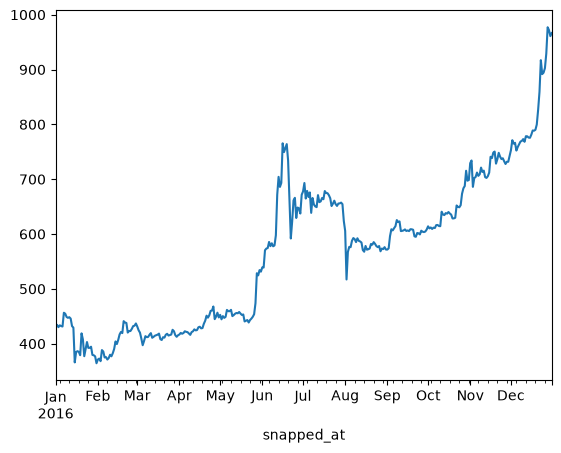

In [8]:
# bitcoin["price"].plot()

bitcoin.loc[ "2016"  , "price" ].plot() # slicing comme sur numpy

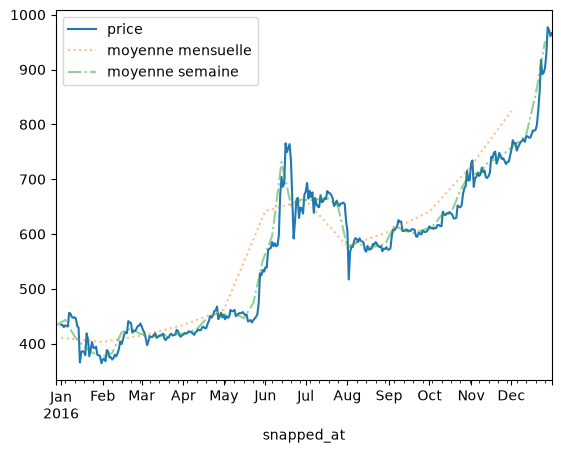

In [16]:
# avoir des indicateurs sur des données temporelles 
# resample() => regrouper les données sur une période

# je veux avoir le prix moyen du bitcoin par mois
import matplotlib.pyplot as plt

bitcoin.loc[ "2016"  , "price" ].resample("ME").mean()
bitcoin.loc[ "2016"  , "price" ].plot()
bitcoin.loc[ "2016"  , "price" ].resample("ME").mean().plot( alpha=0.5 , ls=":", label="moyenne mensuelle")
bitcoin.loc[ "2016"  , "price" ].resample("W").mean().plot( alpha=0.5 , ls="-.", label="moyenne semaine")
plt.legend()

# resample() + agg()
sur une période regroupé temporellement avoir plusieurs indicateurs

In [17]:
bitcoin.loc[ "2016"  , "price" ].resample("ME").agg(["mean", "min" , "max" , "std"])

,mean,min,max,std
snapped_at,,,,
2016-01-31 00:00:00+00:00,410.816171,364.352000,456.434000,29.434064
2016-02-29 00:00:00+00:00,403.203897,368.124000,441.120000,25.484347
2016-03-31 00:00:00+00:00,414.869839,397.241000,431.371000,6.419787
2016-04-30 00:00:00+00:00,434.204867,416.145000,467.856000,15.570636
2016-05-31 00:00:00+00:00,461.975226,438.675000,534.224000,27.495541
2016-06-30 00:00:00+00:00,642.125542,538.832000,765.463000,68.108952
2016-07-31 00:00:00+00:00,661.853865,623.745771,693.047000,13.417073
2016-08-31 00:00:00+00:00,577.688033,517.134929,605.747000,14.204655
2016-09-30 00:00:00+00:00,604.714605,571.590000,625.467500,11.187839


utiliser ces indicateurs dans un graph

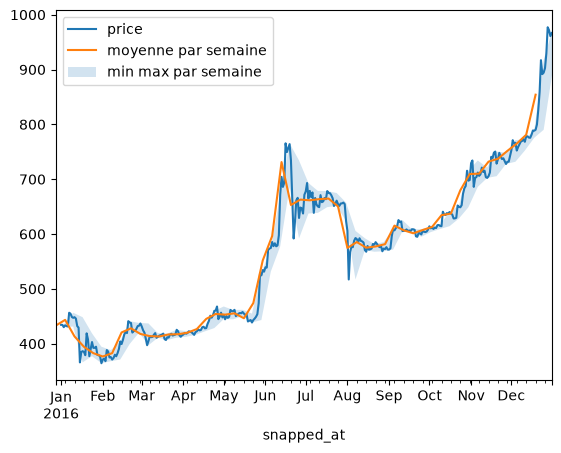

In [19]:
m = bitcoin.loc["2016", "price"].resample("W").agg(["mean","min", "max"])

plt.figure()

bitcoin.loc[ "2016"  , "price" ].plot()
m["mean"]["2016"].plot(label="moyenne par semaine")
plt.fill_between(
            m.index, # date de la période année 2016
            m["max"],  
            m["min"], 
            alpha=0.2 , 
            label="min max par semaine")

plt.legend()


exo : pouvez créer un graphique qui affiche sur la même figure
- le cours moyen du bitcoin mensuel x
- le cours moyen du bitcoin à la semaine
- le min et max de la devise mensuel

sur la période 2026 (réponse dans le tchat de teams)

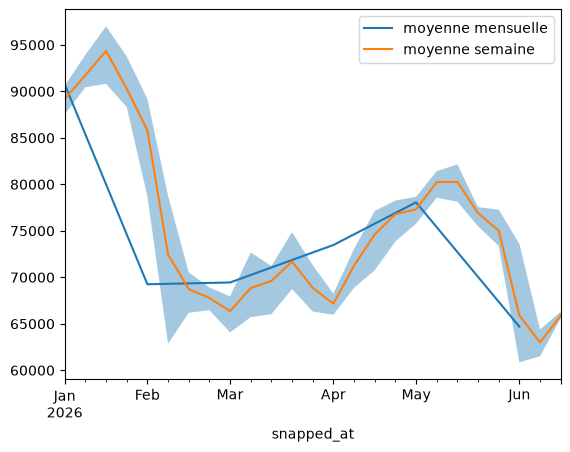

In [29]:
m = bitcoin.loc["2026", "price"].resample("W").agg(["min", "max"])

plt.figure()
bitcoin.loc["2026", "price"].resample("ME").mean().plot( label="moyenne mensuelle")
bitcoin.loc["2026", "price"].resample("W").mean().plot( label="moyenne semaine")
plt.fill_between( 
    m.index,
    m["max"],
    m["min"],
    alpha=0.4
)

plt.legend()

autre type de moyenne que l'on peut utiliser => moyenne mobile
prendre une période => les 7 derniers jours (window) et faire la moyenne sur cette période
puis décaler d'un jour et relancer le calcul de moyenne

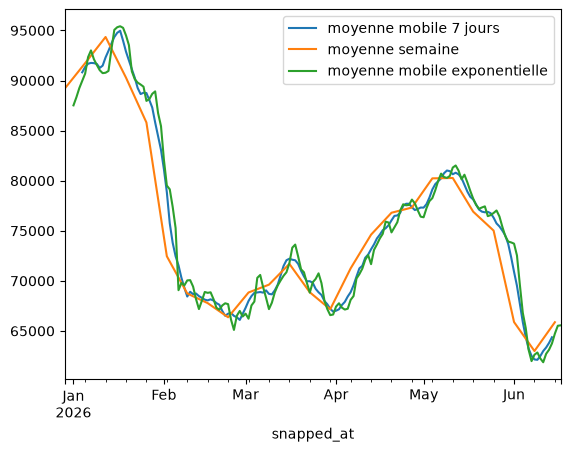

In [ ]:
bitcoin.loc["2026", "price"].rolling( window=7, center=True ).mean().plot( label="moyenne mobile 7 jours")
bitcoin.loc["2026", "price"].resample("W").mean().plot( label="moyenne semaine")
plt.legend()
bitcoin.loc["2026", "price"].ewm( alpha=0.5 ) .mean().plot( label="moyenne mobile exponentielle")
plt.legend()
# moyenne mobile exponentielle => permet à la moyenne d'être sensible aux évolutions avec beaucoup de volatilité
# attention ici alpha c'est le facteur de lissage de la courbe

exo créer un graph qui afficher sur la période 2026

le cours du bitcoin 
la moyenne moyenne exponentielle pour un alpha de 0.2
la moyenne moyenne exponentielle pour un alpha de 0.4
la moyenne moyenne exponentielle pour un alpha de 0.6
la moyenne moyenne exponentielle pour un alpha de 0.8

ne pas hésiter à utiliser une boucle for 
répondre dans le tchat Teams ! MERCI !

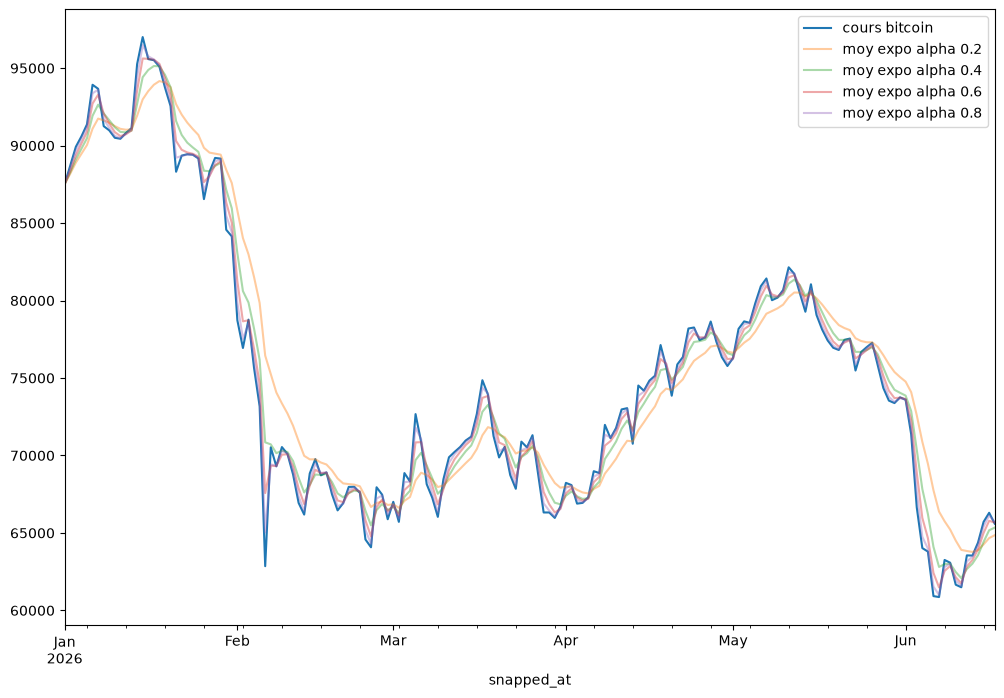

In [46]:
import numpy as np

plt.figure(figsize=(12,8)) # grandir les dimensions du graphique

bitcoin.loc[ "2026"  , "price" ].plot( label="cours bitcoin")

for alpha in np.arange(0.2, 1, 0.2):
    round_alpha = round(alpha, 1)
    bitcoin.loc["2026", "price"].ewm( alpha=alpha ).mean().plot( label=f"moy expo alpha { round_alpha }" , alpha=0.4)

plt.legend()

In [47]:
A = np.arange(0.2, 1, 0.2)
A

array([0.2, 0.4, 0.6, 0.8])

In [ ]:
print(0.1 + 0.2) # 0.3 mais 0.30000000000000004

0.30000000000000004


rdv 10h50 bon café !!! @ toute suite !!!!

In [ ]:
# nous avons vu ensemble des fonctions les plus intéressantes pour visualiser et traiter les données temporelles 
# je vous propose de regarder ensemble comme fusionner plusieurs csv dans un meme Dataframe pandas

In [55]:
# ajouter le deuxieme fichier
bitcoin = pd.read_csv("btc-usd-max.csv" , index_col="snapped_at" , parse_dates=True )
etherium = pd.read_csv("eth-usd-max.csv" , index_col="snapped_at" , parse_dates=True )

# fusionner nos deux fichiers 
# utiliser la méthode pandas .merge()
# merge ça ressemble BEAUCOUP au jointure SQL dans laquelle on va définir le type de jointure
# inner / outer / left / right

bit_eth= pd.merge( bitcoin , etherium , on="snapped_at" , how="inner" , suffixes = ["_bit", "_eth"] )

bit_eth.head(2)


,price_bit,market_cap_bit,total_volume_bit,price_eth,market_cap_eth,total_volume_eth
snapped_at,,,,,,
2015-08-07 00:00:00+00:00,278.508814,4.015651e+09,4.763746e+07,2.83162,0.0,90622.0
2015-08-08 00:00:00+00:00,259.800728,3.745911e+09,8.005622e+07,1.33075,80339475.0,368070.0


<Axes: xlabel='snapped_at'>

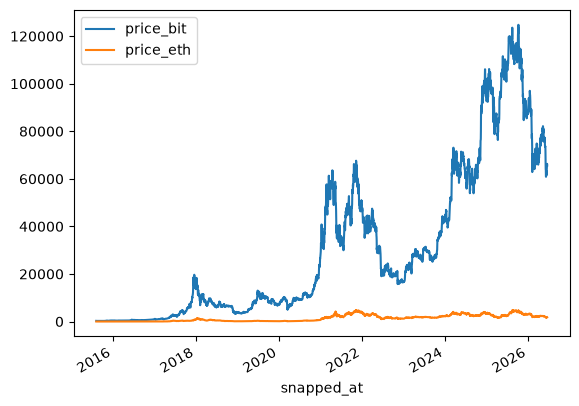

In [56]:
bit_eth[[ "price_bit" , "price_eth" ]].plot()

array([<Axes: xlabel='snapped_at'>, <Axes: xlabel='snapped_at'>],
      dtype=object)

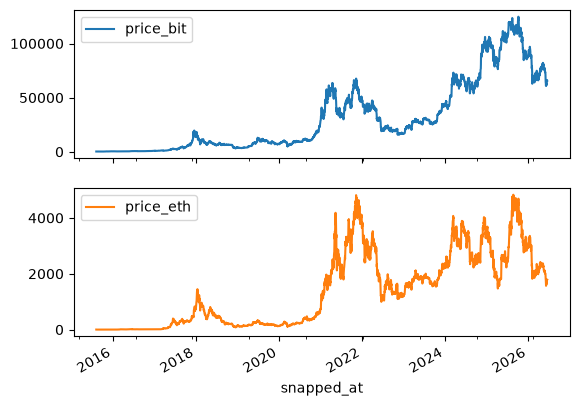

In [57]:
bit_eth[[ "price_bit" , "price_eth" ]].plot(subplots=True)

voir si les deux courbes sont corrélées en utilisant le fonction .corr()

In [ ]:
bit_eth[[ "price_bit" , "price_eth" ]].corr()
# le bitcoin et l etherium se suivent à 87% 
# l'évolution de l'un permet de savoir l'evolution de l'autre !!! 

,price_bit,price_eth
price_bit,1.000000,0.871757
price_eth,0.871757,1.000000


correction

In [59]:
student_data1 = pd.DataFrame({
        'student_id': ['S1', 'S2', 'S3', 'S4', 'S5'],
         'name': ['Danniella Fenton', 'Ryder Storey', 'Bryce Jensen', 'Ed Bernal', 'Kwame Morin'], 
        'marks': [200, 210, 190, 222, 199]})

student_data2 = pd.DataFrame({
        'student_id': ['S4', 'S5', 'S6', 'S7', 'S8'],
        'name': ['Scarlette Fisher', 'Carla Williamson', 'Dante Morse', 'Kaiser William', 'Madeeha Preston'], 
        'marks': [201, 200, 198, 219, 201]})

exam_data = pd.DataFrame({
        'student_id': ['S1', 'S2', 'S3', 'S4', 'S5', 'S7', 'S8', 'S9', 'S10', 'S11', 'S12', 'S13'],
        'exam_id': [23, 45, 12, 67, 21, 55, 33, 14, 56, 83, 88, 12]})


# fusion vertical les données étudiant

etudiants = pd.concat([student_data1 , student_data2])
etudiants

,student_id,name,marks
0,S1,Danniella Fenton,200
1,S2,Ryder Storey,210
2,S3,Bryce Jensen,190
3,S4,Ed Bernal,222
4,S5,Kwame Morin,199
0,S4,Scarlette Fisher,201
1,S5,Carla Williamson,200
2,S6,Dante Morse,198
3,S7,Kaiser William,219
4,S8,Madeeha Preston,201


In [60]:
final = pd.merge(etudiants , exam_data , on="student_id")
final

,student_id,name,marks,exam_id
0,S1,Danniella Fenton,200,23
1,S2,Ryder Storey,210,45
2,S3,Bryce Jensen,190,12
3,S4,Ed Bernal,222,67
4,S5,Kwame Morin,199,21
5,S4,Scarlette Fisher,201,67
6,S5,Carla Williamson,200,21
7,S7,Kaiser William,219,55
8,S8,Madeeha Preston,201,33


In [69]:
student_data1 = pd.DataFrame({
        'student_id': ['S1', 'S2', 'S3', 'S4', 'S5'],
         'name': ['Danniella Fenton', 'Ryder Storey', 'Bryce Jensen', 'Ed Bernal', 'Kwame Morin'], 
        'marks': [200, 210, 190, 222, 199]})


# ajouter une nouvelle ligne dans un DataFrame
# ajoute une Serie
"""
student_id                  S6
name          Scarlette Fisher
marks                      205
"""
nouvel_etudiant = pd.DataFrame({
        'student_id': ['S6'],
        'name': ['Scarlette Fisher'], 
        'marks': [205]      
})

print(nouvel_etudiant)

combinaison = pd.concat( [student_data1 , nouvel_etudiant]  )

print(combinaison)


  student_id              name  marks
0         S6  Scarlette Fisher    205
  student_id              name  marks
0         S1  Danniella Fenton    200
1         S2      Ryder Storey    210
2         S3      Bryce Jensen    190
3         S4         Ed Bernal    222
4         S5       Kwame Morin    199
0         S6  Scarlette Fisher    205


Turtle strategie

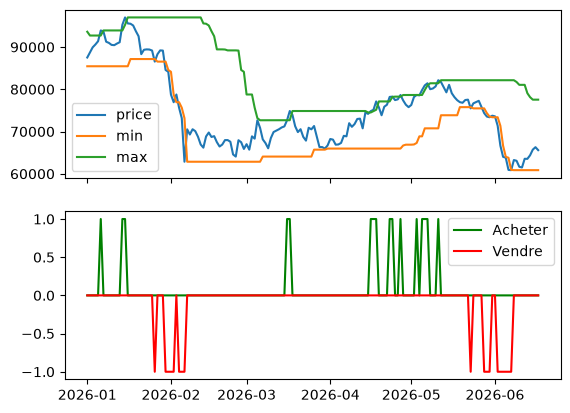

In [72]:
import numpy as np
# copie du dataset dans la variable data
data = bitcoin.copy()

# créer 2 tableaux qui contiennent que des 0 mais qui ont le même nombre de ligne que data
data["Acheter"] = np.zeros(len(data))
data["Vendre"] = np.zeros(len(data))

# fait récupérer le min et max sur les 28 derniers jours
# il faut décaler d'1 jour .shift(1)
data["RollingMax"] = data["price"].shift(1).rolling(window=28).max()
data["RollingMin"] = data["price"].shift(1).rolling(window=28).min()

# acheter ou vendre 
data.loc[data["RollingMax"] < data['price'] , "Acheter"] = 1
data.loc[data["RollingMin"] > data['price'] , "Vendre"] = -1

start = "2026-01"
end = "2026-06"

fig, ax = plt.subplots(2,1,sharex=True)
ax[0].plot(data.loc[start:end, "price"])
ax[0].plot(data.loc[start:end, "RollingMin"])
ax[0].plot(data.loc[start:end, "RollingMax"])
ax[0].legend(["price", "min", "max"])

ax[1].plot(data["Acheter"][start:end], c="g")
ax[1].plot(data["Vendre"][start:end], c="r")
ax[1].legend(["Acheter", "Vendre"])


Bon appétit => rdv 13h40 @ toute suite ! Bon appetit !!!